This notebook is for searching for the best set of hyperparameters for all methods in part 1 generalization paper.

In [ ]:
# Data collection command:
# `python comet_download.py --project=generalization-paper-draft-v2-sgd-baselines --n_threads=8`

In [1]:
import itertools
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from phd.feature_search.analysis.plotting_utils import *
from phd.feature_search.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

In [2]:
# TODO: Switch to v2 data after the sweeps are run

save_path = 'figures/'
config_data_path = 'data/generalization-paper-draft-v2-sgd-baselines_params.csv'
run_data_path = f'data/generalization-paper-draft-v2-sgd-baselines_metrics.csv'

all_sweeps_config_df = pd.read_csv(config_data_path, index_col=0)
all_sweeps_run_df = pd.read_csv(run_data_path, index_col=0)

# Remove duplicate config rows, ignoring run_id column
all_sweeps_config_df = all_sweeps_config_df.drop_duplicates(
    subset = [col for col in all_sweeps_config_df.columns if col != 'run_id'],
    keep = 'last',
)
valid_run_ids = set(all_sweeps_config_df['run_id'].unique())
all_sweeps_run_df = all_sweeps_run_df[all_sweeps_run_df['run_id'].isin(valid_run_ids)]
all_sweeps_run_df = all_sweeps_run_df.dropna(subset=['step'])

sweep_names = list(all_sweeps_config_df['sweep_name'].unique())

# Split up dfs by sweep name
run_dfs = {}
config_dfs = {}
for sweep_name in sweep_names:
    config_dfs[sweep_name] = all_sweeps_config_df[all_sweeps_config_df['sweep_name'] == sweep_name].reset_index(drop=True)
    # Drop experiments that did not complete
    max_step = config_dfs[sweep_name]['curr_step'].max()
    config_dfs[sweep_name] = config_dfs[sweep_name][config_dfs[sweep_name]['curr_step'] == max_step]
    
    run_ids = set(config_dfs[sweep_name]['run_id'].unique())
    run_dfs[sweep_name] = all_sweeps_run_df[all_sweeps_run_df['run_id'].isin(run_ids)].reset_index(drop=True)

{k: len(v) for k, v in config_dfs.items()}

{'sgd_and_nap': 35, 'sgd_e2e': 35, 'sgd_and_search_input_layer': 735}

In [6]:
sweep_ablation_vars = {
    'sgd_e2e': [
        'optimizer.learning_rate',
    ],
    'sgd_and_nap': [
        'optimizer.learning_rate',
    ],
    'sgd_and_search_input_layer': [
        'representation_optimizer.learning_rate',
        'optimizer.meta_learning_rate',
        'feature_recycling.recycle_rate',
    ],
}

In [11]:
best_config_dfs = {}
best_run_dfs = {}

# Define how to split categories for each sweep
sweep_split_vars = {
    'sgd_e2e': [],
    'sgd_and_nap': [],
    'sgd_and_search_input_layer': [],
}

for sweep_name in config_dfs.keys():
    # Skip sweeps where we aren't doing a step-size ablation
    if sweep_name not in sweep_ablation_vars:
        continue

    config_df = config_dfs[sweep_name]
    run_df = run_dfs[sweep_name]
    ablation_vars = sweep_ablation_vars[sweep_name]
    split_vars = sweep_split_vars[sweep_name]

    if isinstance(ablation_vars, str):
        ablation_vars = [ablation_vars]

    # Get unique values for each ablation variable
    ablation_var_values = {var: config_df[var].unique() for var in ablation_vars}

    # Merge config info into run df
    merge_cols = ['run_id'] + split_vars + ablation_vars
    run_df_with_ablation = run_df.merge(
        config_df[merge_cols],
        on='run_id',
        how='left'
    )

    # Calculate mean loss grouped by ablation vars and split vars
    groupby_cols = ablation_vars + split_vars
    mean_loss = run_df_with_ablation.groupby(groupby_cols)['loss'].mean()

    print(f"\n=== {sweep_name} ===")

    # Handle case where split_vars is an empty list
    if len(split_vars) == 0:
        split_combinations = [()]  # Single combination: ()
    else:
        split_var_values = [sorted(config_df[var].unique()) for var in split_vars]
        split_combinations = list(itertools.product(*split_var_values))

    # Find best ablation values for each split combination
    best_run_ids = []
    for split_vals in split_combinations:
        if len(split_vars) == 0:
            config_str = "\nConfiguration: (no split vars)"
        else:
            config_str = "\nConfiguration: "
            config_str += " | ".join(
                f"{var}={val:.2e}" if isinstance(val, float) else f"{var}={val}"
                for var, val in zip(split_vars, split_vals)
            )
        print(config_str)

        # Build query for this split combination
        split_query = pd.Series(True, index=mean_loss.index)
        for var, val in zip(split_vars, split_vals):
            split_query &= (mean_loss.index.get_level_values(var) == val)

        # Get losses for this split combination
        split_losses = mean_loss[split_query]
        best_loss_idx = split_losses.idxmin()

        # If there are no split vars, best_loss_idx might not be a tuple, forcibly turn to tuple for indexing
        if len(ablation_vars) == 1 and not isinstance(best_loss_idx, tuple):
            best_loss_idx_tuple = (best_loss_idx,)
        else:
            best_loss_idx_tuple = best_loss_idx

        # Print best ablation values
        for i, var in enumerate(ablation_vars):
            val = best_loss_idx_tuple[i]
            if isinstance(val, str):
                print(f"  Best {var}={val}")
            else:
                print(f"  Best {var}={val:.2e}")

        # Get run_ids for this best configuration
        query = pd.Series(True, index=config_df.index)
        for var, val in zip(split_vars, split_vals):
            query &= (config_df[var] == val)
        for var, val in zip(ablation_vars, best_loss_idx_tuple[:len(ablation_vars)]):
            query &= (config_df[var] == val)

        matching_runs = config_df[query]
        assert len(matching_runs) > 0
        best_run_ids.extend(matching_runs['run_id'].tolist())

    best_config_dfs[sweep_name] = config_df[config_df['run_id'].isin(best_run_ids)]
    best_run_dfs[sweep_name] = run_df[run_df['run_id'].isin(best_run_ids)]

{k: len(v) for k, v in best_config_dfs.items()}


=== sgd_and_nap ===

Configuration: (no split vars)
  Best optimizer.learning_rate=${eval:2**-10}

=== sgd_e2e ===

Configuration: (no split vars)
  Best optimizer.learning_rate=${eval:2**-10}

=== sgd_and_search_input_layer ===

Configuration: (no split vars)
  Best representation_optimizer.learning_rate=${eval:2**2}
  Best optimizer.meta_learning_rate=5.00e-03
  Best feature_recycling.recycle_rate=0.00e+00


{'sgd_and_nap': 5, 'sgd_e2e': 5, 'sgd_and_search_input_layer': 5}

## Baseline Comparison

#### Best hyperparams

In [ ]:
combined_best_config_df = pd.concat(list(best_config_dfs.values()), ignore_index=True)
combined_best_run_df = pd.concat(
    [df.assign(method=method) for method, df in best_run_dfs.items()],
    ignore_index=True
)

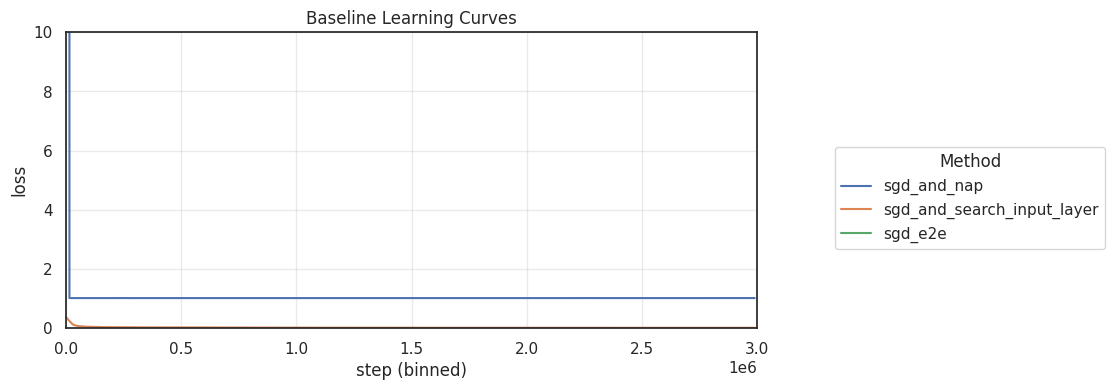

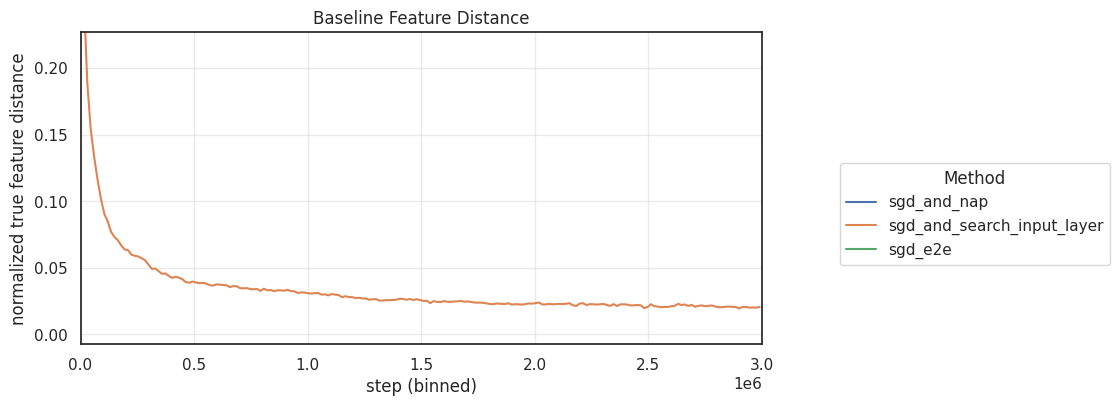

In [43]:
### Best hyperparams per target net flip rate ###

plot_learning_curves(
    run_df = combined_best_config_df,
    config_df = combined_best_run_df,
    n_bins = 200,
    figsize = (8, 4),
    hue_col = 'method',
    legend_title = 'Method',
)
plt.ylim(0, 10)
plt.title('Baseline Learning Curves')
plt.show()

plot_learning_curves(
    run_df = combined_best_config_df,
    config_df = combined_best_run_df,
    n_bins = 200,
    figsize = (8, 4),
    y_col = 'feature_match/average_best_match_normalized_distance',
    y_label = 'normalized true feature distance',
    hue_col = 'method',
    legend_title = 'Method',
)
plt.title('Baseline Feature Distance')
plt.show()
    
# )
# plt.title('True Feature Distance with SGD Input Layer - Best Hyperparams')

## End-to-end SGD

Text(0.5, 1.0, 'End-to-End SGD')

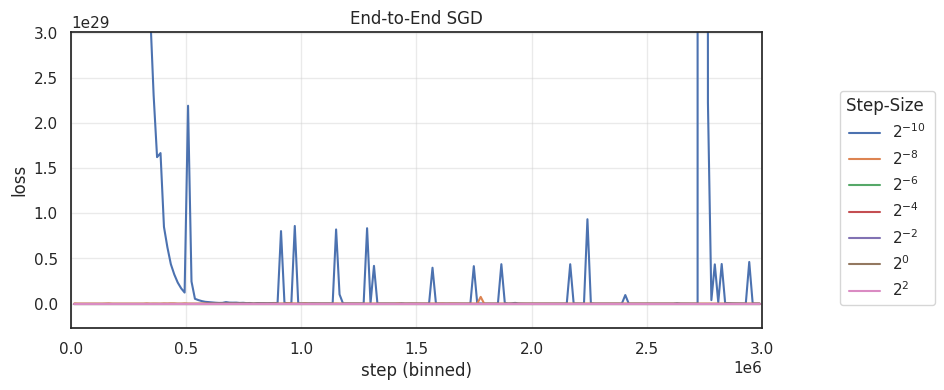

In [45]:
plot_learning_curves(
    run_df = run_dfs['sgd_e2e'],
    config_df = config_dfs['sgd_e2e'],
    n_bins = 200,
    figsize = (8, 4),
    hue_col = 'optimizer|learning_rate',
    pow_2_legend = True,
    legend_title = 'Step-Size ',
)
plt.title('End-to-End SGD')

## Feature Search

Text(0.5, 1.0, 'Feature Search Learning Curve')

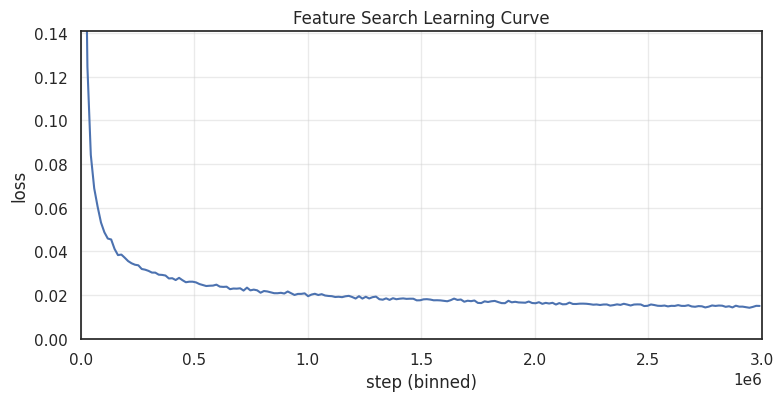

In [48]:
plot_learning_curves(
    run_df = best_run_dfs['sgd_and_search_input_layer'],
    config_df = best_config_dfs['sgd_and_search_input_layer'],
    n_bins = 200,
    figsize = (8, 4),
)
plt.title('Feature Search Learning Curve')

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


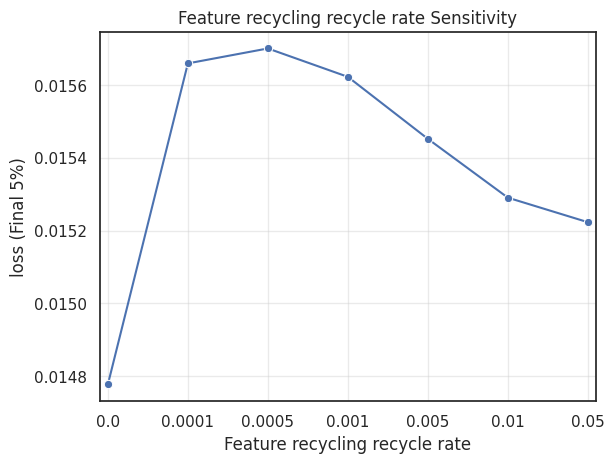

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


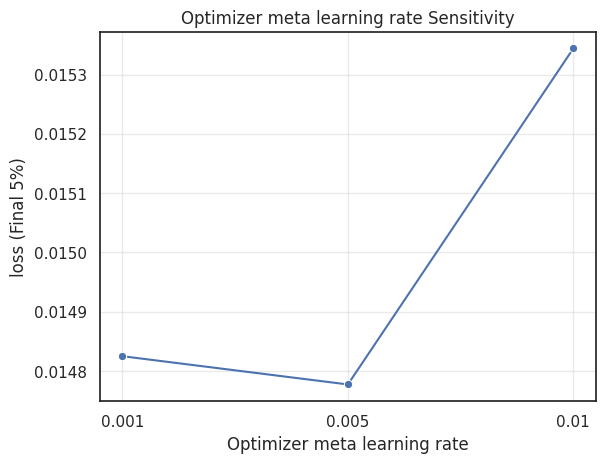

/home/edan/local_projects/phd_research/phd/feature_search/analysis/plotting.py:81: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


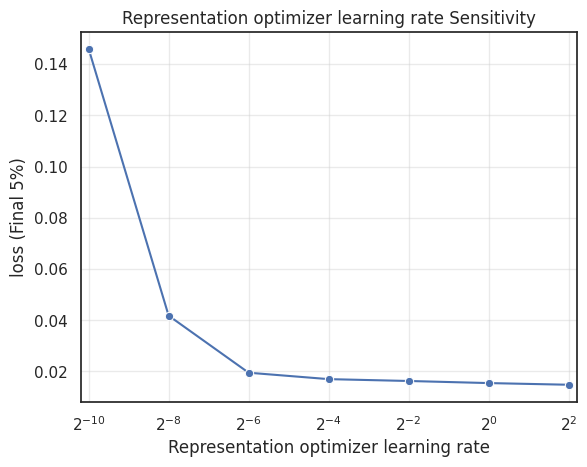

In [53]:
default_hyperparams = {
    'feature_recycling|recycle_rate': 0.0,
    'optimizer|meta_learning_rate': 0.005,
    'representation_optimizer|learning_rate': 4.0,
}

for param_name, param_value in default_hyperparams.items():
    selected_run_df, selected_config_df = select_experiment_runs(
        run_df = run_dfs['sgd_and_search_input_layer'],
        config_df = config_dfs['sgd_and_search_input_layer'],
        chosen_values = {
            k: v for k, v in default_hyperparams.items()
            if k != param_name
        },
    )
    
    param_label = param_name.replace('|', ' ').replace('_', ' ').capitalize()
    
    plot_param_sensitivity(
            run_df = selected_run_df,
            config_df = selected_config_df,
            x_col = param_name,
            title = f'{param_label} Sensitivity',
            x_label = param_label,
            y_label = 'loss',
            metric_col = 'loss',
            metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
            step_col = 'step',
            show_ci = False,
            baseline_col = None,
            pow_2_x_axis = 'repr' in param_name,
        )
    plt.show()

#### Selected hyperparams

Text(0.5, 1.0, 'True Feature Distance with SGD Input Layer - Selected Hyperparams')

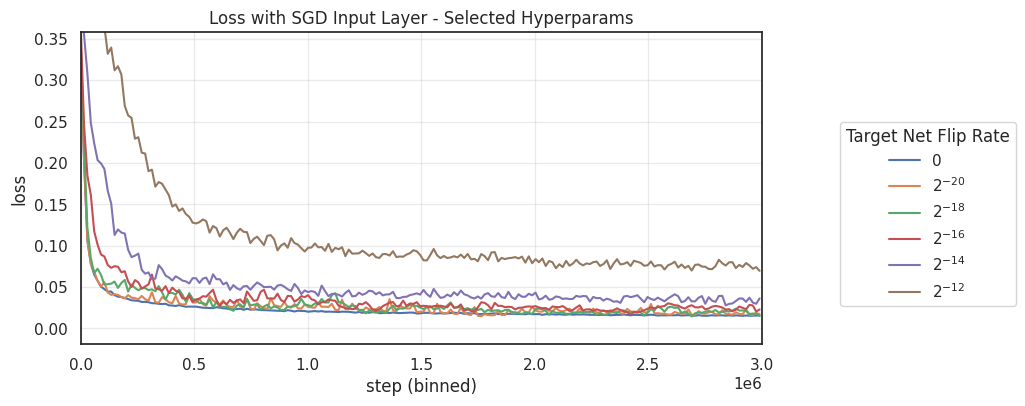

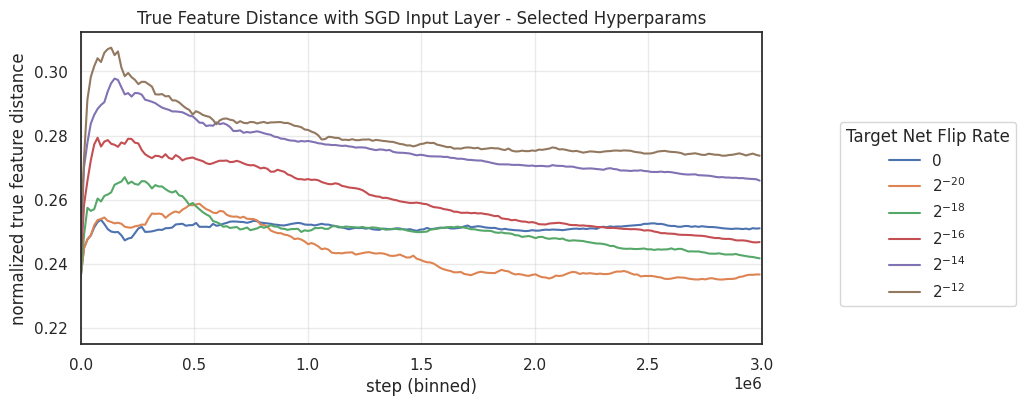

In [8]:
### Single set of selected hyperparams ###

selected_run_df, selected_config_df = select_experiment_runs(
    run_df = run_dfs['sgd_input_layer_vary_ns_and_model_size'],
    config_df = config_dfs['sgd_input_layer_vary_ns_and_model_size'],
    chosen_values = {
        'optimizer|learning_rate': 0.03 / 5120 ** 0.75,
        'optimizer|meta_learning_rate': 0.01,
        'representation_optimizer|learning_rate': 2.0,
    },
)

plot_learning_curves(
    run_df = selected_run_df,
    config_df = selected_config_df,
    n_bins = 200,
    figsize = (8, 4),
    max_cols = 2,
    same_y_axis = True,
    hue_col = 'task|flip_rate',
    pow_2_legend = True,
    legend_title = 'Target Net Flip Rate',
)
plt.title('Loss with SGD Input Layer - Selected Hyperparams')

plot_learning_curves(
    run_df = selected_run_df,
    config_df = selected_config_df,
    n_bins = 200,
    figsize = (8, 4),
    max_cols = 2,
    same_y_axis = True,
    y_col = 'feature_match/average_best_match_normalized_distance',
    y_label = 'normalized true feature distance',
    hue_col = 'task|flip_rate',
    pow_2_legend = True,
    legend_title = 'Target Net Flip Rate',
)
plt.axhline(y=20, color='black', linestyle='--', alpha=0.8)
plt.title('True Feature Distance with SGD Input Layer - Selected Hyperparams')

#### Long Run

Text(0.5, 1.0, 'True Feature Distance with SGD Input Layer - Long Run')

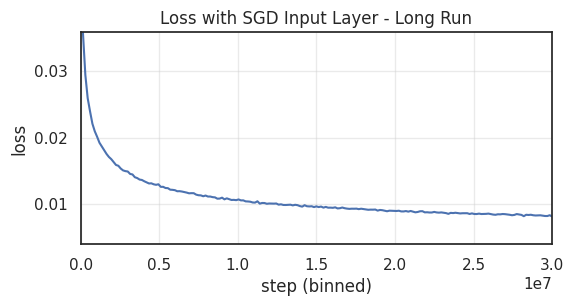

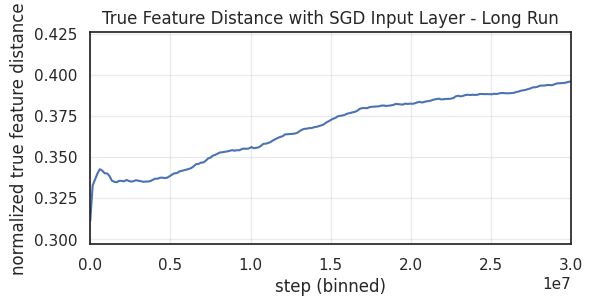

In [ ]:
selected_run_df, selected_config_df = select_experiment_runs(
    run_df = run_dfs['sgd_input_layer_vary_ns_long_run'],
    config_df = config_dfs['sgd_input_layer_vary_ns_long_run'],
    chosen_values = {
        'optimizer|meta_learning_rate': 0.001,
        'representation_optimizer|learning_rate': 8.0,
    },
)

plot_learning_curves(
    run_df = selected_run_df,
    config_df = selected_config_df,
    n_bins = 200,
    figsize = (6, 3),
)
plt.title('Loss with SGD Input Layer - Long Run')

plot_learning_curves(
    run_df = selected_run_df,
    config_df = selected_config_df,
    n_bins = 200,
    figsize = (6, 3),
    y_col = 'feature_match/average_best_match_normalized_distance',
    y_label = 'normalized true feature distance',
)
plt.title('True Feature Distance with SGD Input Layer - Long Run')

#### SGD + search on input layer

In [ ]:


plot_learning_curves(
    run_df = selected_run_df,
    config_df = selected_config_df,
    n_bins = 200,
    figsize = (6, 3),
)
plt.title('Loss with SGD Input Layer - Long Run')

plot_learning_curves(
    run_df = selected_run_df,
    config_df = selected_config_df,
    n_bins = 200,
    figsize = (6, 3),
    y_col = 'feature_match/average_best_match_normalized_distance',
    y_label = 'normalized true feature distance',
)
plt.title('True Feature Distance with SGD Input Layer - Long Run')

### Hyperparam sensitivity

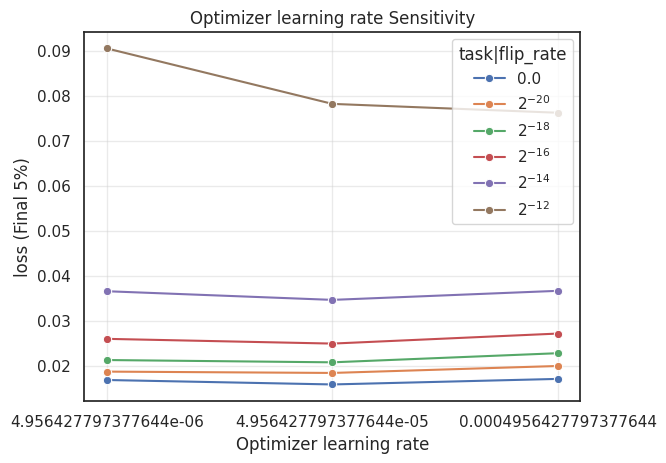

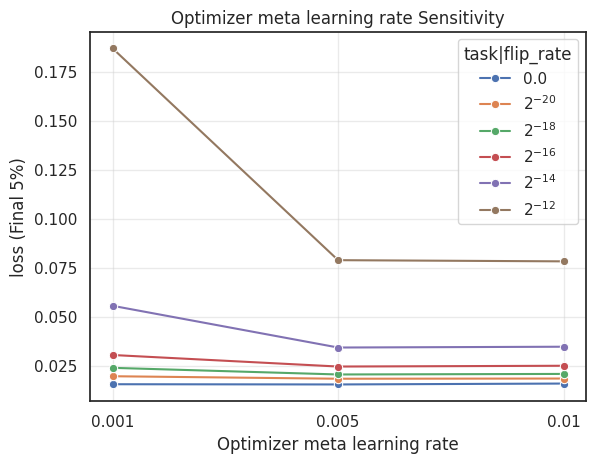

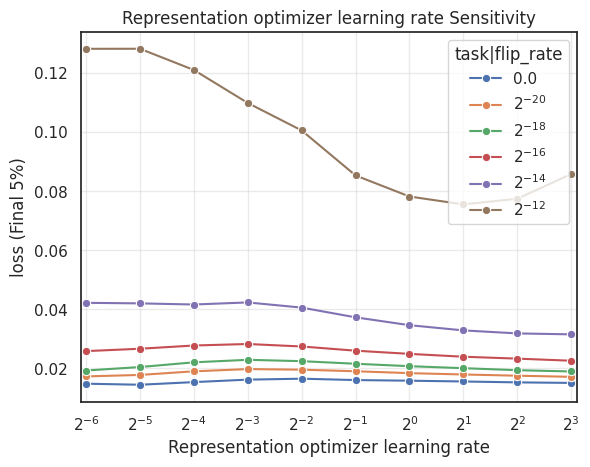

In [9]:
default_hyperparams = {
    'optimizer|learning_rate': 0.03 / 5120 ** 0.75,
    'optimizer|meta_learning_rate': 0.01,
    'representation_optimizer|learning_rate': 1.0,
}

for param_name, param_value in default_hyperparams.items():
    selected_run_df, selected_config_df = select_experiment_runs(
        run_df = run_dfs['sgd_input_layer_vary_ns_and_model_size'],
        config_df = config_dfs['sgd_input_layer_vary_ns_and_model_size'],
        chosen_values = {
            k: v for k, v in default_hyperparams.items()
            if k != param_name
        },
    )
    
    param_label = param_name.replace('|', ' ').replace('_', ' ').capitalize()
    
    plot_param_sensitivity(
            run_df = selected_run_df,
            config_df = selected_config_df,
            x_col = param_name,
            title = f'{param_label} Sensitivity',
            x_label = param_label,
            y_label = 'loss',
            metric_col = 'loss',
            metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
            step_col = 'step',
            hue_col = 'task|flip_rate',
            legend_title = None,
            show_ci = False,
            baseline_col = None,
            pow_2_x_axis = 'repr' in param_name,
            pow_2_legend = True,
        )
    plt.show()

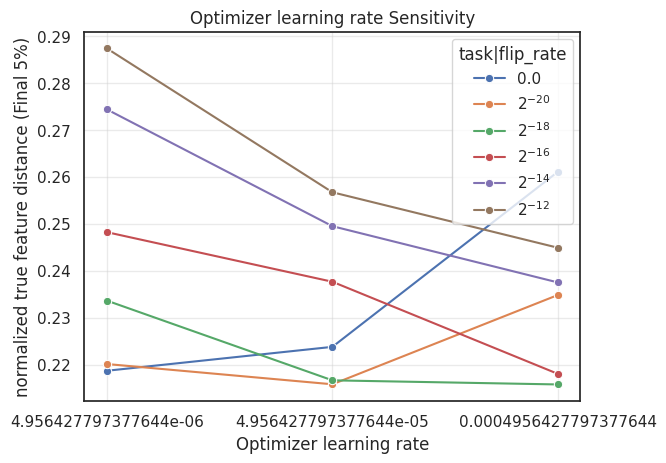

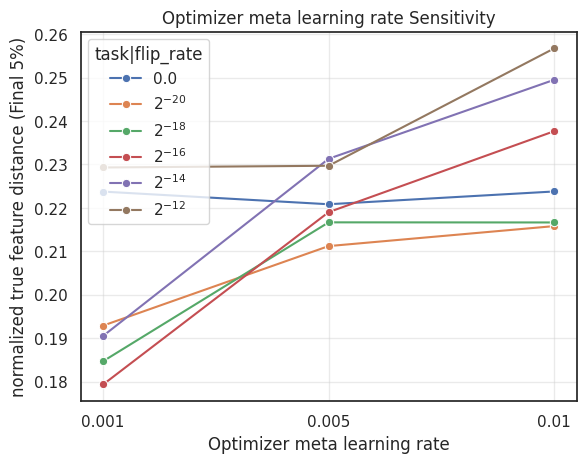

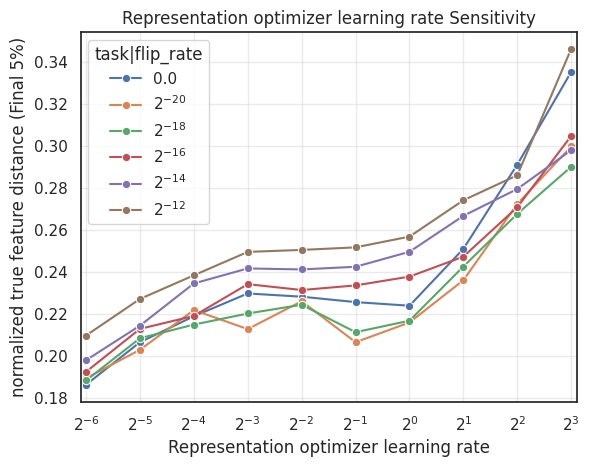

In [29]:
default_hyperparams = {
    'optimizer|learning_rate': 0.03 / 5120 ** 0.75,
    'optimizer|meta_learning_rate': 0.01,
    'representation_optimizer|learning_rate': 1.0,
}

for param_name, param_value in default_hyperparams.items():
    selected_run_df, selected_config_df = select_experiment_runs(
        run_df = run_dfs['sgd_input_layer_vary_ns_and_model_size'],
        config_df = config_dfs['sgd_input_layer_vary_ns_and_model_size'],
        chosen_values = {
            k: v for k, v in default_hyperparams.items()
            if k != param_name
        },
    )
    
    param_label = param_name.replace('|', ' ').replace('_', ' ').capitalize()
    
    plot_param_sensitivity(
            run_df = selected_run_df,
            config_df = selected_config_df,
            x_col = param_name,
            title = f'{param_label} Sensitivity',
            x_label = param_label,
            y_label = 'normalized true feature distance',
            metric_col = 'feature_match/average_best_match_normalized_distance',
            metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
            step_col = 'step',
            hue_col = 'task|flip_rate',
            legend_title = None,
            show_ci = False,
            baseline_col = None,
            pow_2_x_axis = 'repr' in param_name,
            pow_2_legend = True,
        )
    plt.show()

## SGD instead of Autostep

Text(0.5, 1.0, 'Perfect Feature Matches with SGD Output Layer')

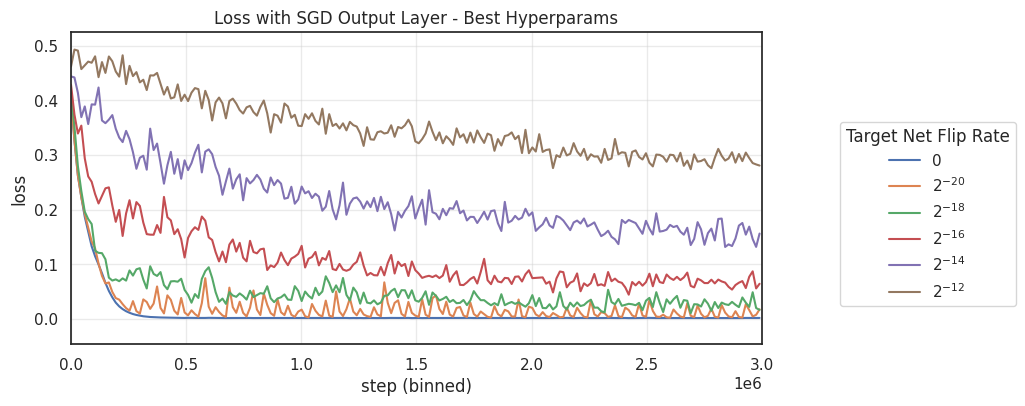

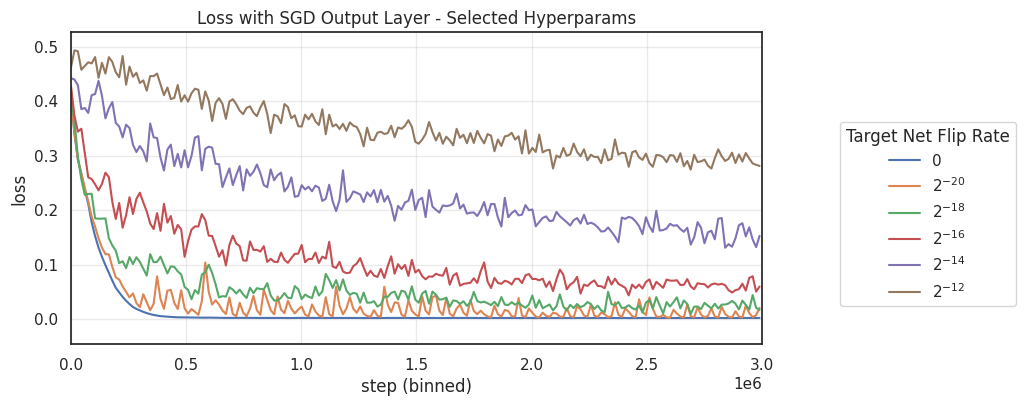

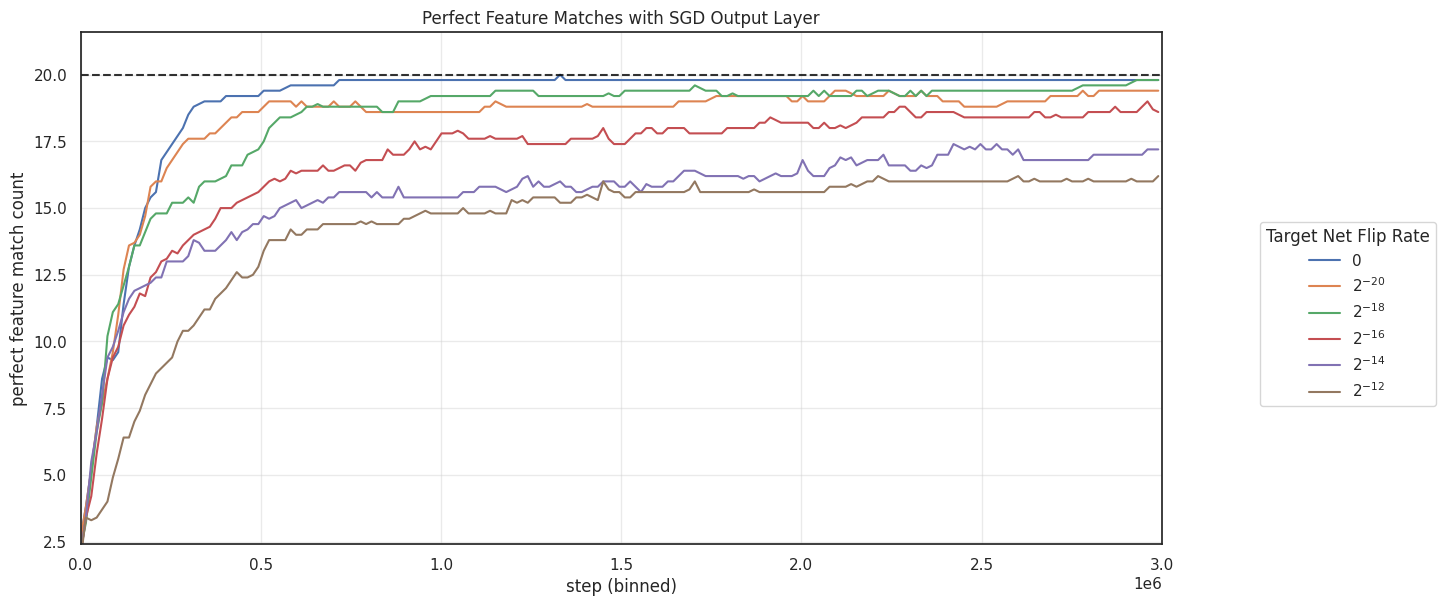

In [10]:
### Best hyperparams per target net flip rate ###

plot_learning_curves(
    run_df = best_run_dfs['ns_no_autostep_sweep'],
    config_df = best_config_dfs['ns_no_autostep_sweep'],
    n_bins = 200,
    figsize = (8, 4),
    max_cols = 2,
    same_y_axis = True,
    hue_col = 'task|flip_rate',
    pow_2_legend = True,
    legend_title = 'Target Net Flip Rate',
)
plt.title('Loss with SGD Output Layer - Best Hyperparams')


### Single set of selected hyperparams ###

run_df = run_dfs['ns_no_autostep_sweep']
config_df = config_dfs['ns_no_autostep_sweep']
selected_run_df, selected_config_df = select_experiment_runs(
    run_df = run_df,
    config_df = config_df,
    chosen_values = {
        'optimizer|learning_rate': 2**-13,
        'feature_recycling|recycle_rate': 0.005,
        'feature_recycling|utility_decay': 0.9999},
)

plot_learning_curves(
    run_df = selected_run_df,
    config_df = selected_config_df,
    n_bins = 200,
    figsize = (8, 4),
    max_cols = 2,
    same_y_axis = True,
    hue_col = 'task|flip_rate',
    pow_2_legend = True,
    legend_title = 'Target Net Flip Rate',
)
plt.title('Loss with SGD Output Layer - Selected Hyperparams')

plot_learning_curves(
    run_df = best_run_dfs['ns_no_autostep_sweep'],
    config_df = best_config_dfs['ns_no_autostep_sweep'],
    n_bins = 200,
    figsize = (12, 6),
    max_cols = 2,
    same_y_axis = True,
    y_col = 'feature_match/perfect_match_count',
    y_label = 'perfect feature match count',
    hue_col = 'task|flip_rate',
    pow_2_legend = True,
    legend_title = 'Target Net Flip Rate',
)
plt.axhline(y=20, color='black', linestyle='--', alpha=0.8)
plt.title('Perfect Feature Matches with SGD Output Layer')

### Hyperparam sensitivity

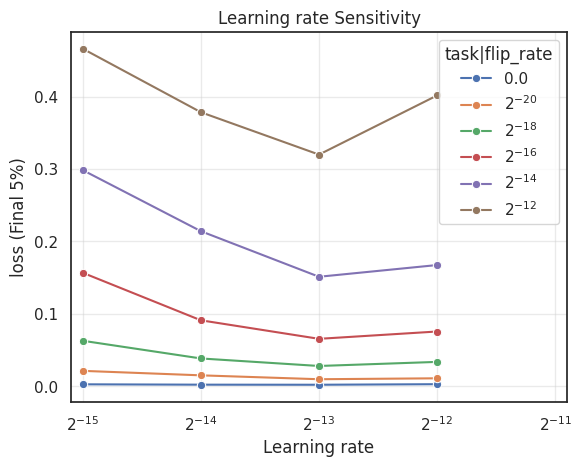

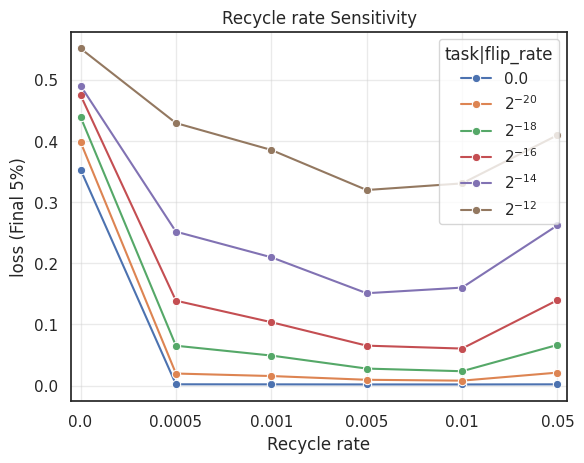

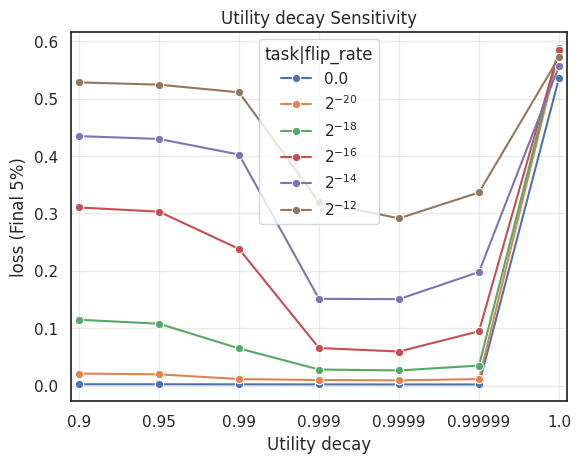

In [11]:
default_hyperparams = {
    'optimizer|learning_rate': 2**-13,
    'feature_recycling|recycle_rate': 0.005,
    'feature_recycling|utility_decay': 0.999,
}

for param_name, param_value in default_hyperparams.items():
    selected_run_df, selected_config_df = select_experiment_runs(
        run_df = run_df,
        config_df = config_df,
        chosen_values = {
            k: v for k, v in default_hyperparams.items()
            if k != param_name
        },
    )
    
    param_label = param_name.split('|')[-1].replace('_', ' ').capitalize()
    
    plot_param_sensitivity(
            run_df = selected_run_df,
            config_df = selected_config_df,
            x_col = param_name,
            title = f'{param_label} Sensitivity',
            x_label = param_label,
            y_label = 'loss',
            metric_col = 'loss',
            metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
            step_col = 'step',
            hue_col = 'task|flip_rate',
            legend_title = None,
            show_ci = False,
            baseline_col = None,
            pow_2_x_axis = param_name == 'optimizer|learning_rate',
            pow_2_legend = True,
        )
    plt.show()